In [1]:
import numpy as np
from optimizer.data_objects import SimulationParameters, SupplyChainData
from optimizer.run_optimizer import construct_supply_chain_data
from optimizer.math_model_declaration import create_math_model
from optimizer.run_optimizer import optimize
import random
import utils.log as log

logger = log.get_logger("MathOptSolver")

Overview- Model is looking at a classic MFG, Distribution, Store Supply Chain optimization.

Each Manufacturing site has a total capacity, and different cost for shipping to each distribution site.

Each Distribution site receives products from a MFG Site, then fulfilled a Store's replenishment demand, with an associated shipping cost. When a distribution site is opened it must remain opened for x number of days

Each distribution has a fixed recurring cost as well as capacity.

Each store has demand that it must fulfill from the MFG site through the distribution to the final store.

Objective is to minimize the total cost of shipping, plus the cost of maintaining a distribution site.

Model:
Demand is randomly generated for each customer for a 10 day period

Global- looks at the total demand minimizes the cost across the entire horizon
Daily - this model is naive and must make decision on a daily, but it inherits decisions from the previous day. Ex. if a distribution site was opened the day before, it must remain open during this time.

RL - we simulated out the model and try to do daily decision based on our RF model.

Goal is to compare Global vs daily vs RL and see how well they converge.


In [2]:
num_days=10
num_simulations=10 
decision_rolling_period=3
num_distribution_sites=5

distribution_opening_costs = [350, 320, 375, 400, 550]
# distribution_opening_costs = [1000, 100000, 100000, 100000, 100000]
mfg_site_capacity = [600000, 600000]

mean_demand = [20, 30, 25, 40, 35, 28, 32, 50, 26, 38, 34, 27]
# mean_demand = [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100]

std_dev_demand = [20, 18, 15, 20, 20, 5, 5, 12.4, 12.6, 13.8, 13.4, 12.7]
# std_dev_demand = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] # If comparing against daily solves or trying to have stable runs, you need to set the std to 0

# Transportation costs
transport_cost_m_to_d = [
    [3.5, 2.5, 4.5, 2.5, 3.0],  # Manufacturing site 1
    [2.5, 4.5, 5.5, 6.5, 8.5]  # Manufacturing site 2
]
transport_cost_d_to_c = [
    [1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 1
    [2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 2
    [2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 3
    [2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2],  # Distribution site 4
    [2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1]   # Distribution site 5
]

# transport_cost_m_to_d = [
#     [3, 3, 3, 3, 3],  # Manufacturing site 1
#     [3, 3, 3, 3, 3]  # Manufacturing site 2
# ]
# transport_cost_d_to_c = [
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # Distribution site 1
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # Distribution site 2
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # Distribution site 3
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # Distribution site 4
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   # Distribution site 5
# ]

In [3]:
%%capture
### Run global solve ###

# Construct supply chain data, params
sim_params = SimulationParameters(num_days, num_simulations, decision_rolling_period)
supply_chain_data = construct_supply_chain_data(mean_demand, mfg_site_capacity, std_dev_demand, distribution_opening_costs, transport_cost_m_to_d, transport_cost_d_to_c)

# Construct and run optimizer
opening_distribution_costs, total_transport_cost, open_distribution_decisions = optimize(supply_chain_data, sim_params, num_distribution_sites)


Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [1e+00, 6e+02]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 6e+05]
Presolving model
948 rows, 785 cols, 2965 nonzeros  0s
908 rows, 785 cols, 2854 nonzeros  0s

Solving MIP model with:
   908 rows
   785 cols (95 binary, 0 integer, 0 implied int., 690 continuous)
   2854 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   0               inf                  inf        0      0      0         0     0.0s
 T       0       0         0   0.00%   0               17152.385843     100.00%        0      0      0       515     0.0s

Solving report
  Status            Optimal
  Primal bound      17152.3858427
  Dual bound        17152.3858427
  Gap               0%
  Solution status   feasible
                

In [4]:
num_manufacturing_sites = 2
num_distribution_sites = 5
num_customers = 12
num_days = 10
num_simulations = 10
decision_rolling_period = 3

distribution_opening_costs = [350, 320, 375, 400, 550]
mfg_site_capacity = [600000, 600000]

mean_demand = [20, 30, 25, 40, 35, 28, 32, 50, 26, 38, 34, 27]
std_dev_demand = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# # Transportation costs
transport_cost_m_to_d = [
    [3.5, 2.5, 4.5, 2.5, 3.0],
    [2.5, 4.5, 5.5, 6.5, 8.5]
]
transport_cost_d_to_c = [
    [1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 1
    [2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 2
    [2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 3
    [2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2],  # Distribution site 4
    [2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1]   # Distribution site 5
]


In [5]:
average_dc_open = [0 for _ in range(num_distribution_sites)]
average_difference = []
all_days_demand = []

logger.debug('Starting daily simulations')        
for simulation in range(num_simulations):
    logger.debug(f'Simulation # {simulation}')
    
    # Reset tracking variables for each simulation
    open_dc_states = [[0 for _ in range(num_days)] for _ in range(num_distribution_sites)]
    open_dc_state = [0 for _ in range(num_distribution_sites)]
    days_dc_open = [0 for _ in range(num_distribution_sites)]

    daily_demand_data = []
    total_daily_cost = 0

    for day in range(num_days):
        # Simulate demand for the day for each customer
        simulated_demand = [max(0, np.random.normal(mean_demand[c], std_dev_demand[c])) for c in range(num_customers)]
        daily_demand_data.append(simulated_demand)
        
        # Run daily simulation
        adj_opening_cost = [0 if state == 1 else cost for state, cost in zip(open_dc_state, distribution_opening_costs)]
        
        # Construct supply sim params
        sim_params = SimulationParameters(1, 1, decision_rolling_period)

        # Construct supply chain data
        supply_chain_data = construct_supply_chain_data(simulated_demand, mfg_site_capacity, std_dev_demand, adj_opening_cost, transport_cost_m_to_d, transport_cost_d_to_c)

        # Construct and run optimizer
        daily_open_distribution_costs, daily_cost, open_distribution_decisions = optimize(supply_chain_data, sim_params, num_distribution_sites)
        
        total_daily_cost += daily_cost

        for d in range(num_distribution_sites):
            open_dc_states[d][day] = open_distribution_decisions[d]
            open_dc_state[d] = open_distribution_decisions[d]

        for distribution in range(num_distribution_sites):
            average_dc_open[distribution] += open_dc_state[distribution]

            if open_dc_state[distribution] == 1:
                days_dc_open[distribution] += 1
                if days_dc_open[distribution] >= decision_rolling_period:
                    open_dc_state[distribution] = 0
                    days_dc_open[distribution] = 0
            else:
                days_dc_open[distribution] = 0

# Calculate average decisions for daily simulations
average_dc_open = [count / (num_simulations * num_days) for count in average_dc_open]


Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [1e+00, 6e+02]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 6e+05]
Presolving model
87 rows, 75 cols, 270 nonzeros  0s
87 rows, 75 cols, 270 nonzeros  0s

Solving MIP model with:
   87 rows
   75 cols (5 binary, 0 integer, 0 implied int., 70 continuous)
   270 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   0               inf                  inf        0      0      0         0     0.0s
 T       0       0         0   0.00%   0               1957.5           100.00%        0      0      0        50     0.0s

Solving report
  Status            Optimal
  Primal bound      1957.5
  Dual bound        1957.5
  Gap               0%
  Solution status   feasible
                    1957.5 (objective)
  

In [6]:
# Global simulation using the last simulation's demand data
# Construct supply chain data, params
sim_params = SimulationParameters(num_days, num_simulations, decision_rolling_period)
supply_chain_data = construct_supply_chain_data(mean_demand, mfg_site_capacity, std_dev_demand, distribution_opening_costs, transport_cost_m_to_d, transport_cost_d_to_c)

# Construct and run optimizer
global_open_distribution_costs, global_cost, global_dc_open = optimize(supply_chain_data, sim_params, num_distribution_sites)
difference = total_daily_cost - global_cost
print(f'Look Back Solve Total:{round(global_cost,2)}, Daily Solve Total:{round(total_daily_cost,2)}, Difference: {round(difference,2)}')
average_difference.append(difference)


Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [1e+00, 6e+02]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 6e+05]
Presolving model
960 rows, 795 cols, 3005 nonzeros  0s
920 rows, 795 cols, 2894 nonzeros  0s

Solving MIP model with:
   920 rows
   795 cols (95 binary, 0 integer, 0 implied int., 700 continuous)
   2894 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   0               inf                  inf        0      0      0         0     0.0s
 T       0       0         0   0.00%   0               16964            100.00%        0      0      0       547     0.0s

Solving report
  Status            Optimal
  Primal bound      16964
  Dual bound        16964
  Gap               0%
  Solution status   feasible
                    16964 (objec

In [7]:
print("Final DC States for Each Decision Point:")
for d in range(num_distribution_sites):
    print(f"Daily Decision Point Dist {d}: {open_dc_states[d]}")
    print(f"Global Decision Point Dist {d}: {global_dc_open[d]}")

print(f"Avg dc open on daily simulation: {average_dc_open}")

Final DC States for Each Decision Point:
Daily Decision Point Dist 0: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Global Decision Point Dist 0: 0
Daily Decision Point Dist 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Global Decision Point Dist 1: 0
Daily Decision Point Dist 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Global Decision Point Dist 2: 0
Daily Decision Point Dist 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Global Decision Point Dist 3: 1
Daily Decision Point Dist 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Global Decision Point Dist 4: 0
Avg dc open on daily simulation: [0.0, 1.0, 0.0, 0.0, 0.0]


In [8]:
# Output average decisions from daily simulations
print('Average Distribution Site Open Decision over 1000 Simulations and 10 Days:')
for d in range(num_distribution_sites):
    print(f'Distribution Site {d}: {average_dc_open[d]:.2f}')

total_sum = sum(average_difference)
num_elements = len(average_difference)
average = total_sum / num_elements if num_elements > 0 else 0

# Output results from global simulation
print('\nGlobal Simulation Results:')
print(f'Average Difference:{average}')
print('Open Distribution Sites:', global_dc_open)

Average Distribution Site Open Decision over 1000 Simulations and 10 Days:
Distribution Site 0: 0.00
Distribution Site 1: 1.00
Distribution Site 2: 0.00
Distribution Site 3: 0.00
Distribution Site 4: 0.00

Global Simulation Results:
Average Difference:691.0
Open Distribution Sites: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


RL Model

In [9]:
num_manufacturing_sites = 2
num_distribution_sites = 5
num_customers = 12
num_days = 10
num_simulations = 10
decision_rolling_period = 3

distribution_opening_costs = [350, 320, 375, 400, 550]
mfg_site_capacity = [600000, 600000]

mean_demand = [20, 30, 25, 40, 35, 28, 32, 50, 26, 38, 34, 27]
std_dev_demand = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# # Transportation costs
transport_cost_m_to_d = [
    [3.5, 2.5, 4.5, 2.5, 3.0],
    [2.5, 4.5, 5.5, 6.5, 8.5]
]
transport_cost_d_to_c = [
    [1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 1
    [2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 2
    [2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2],  # Distribution site 3
    [2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2],  # Distribution site 4
    [2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1]   # Distribution site 5
]

In [10]:
class QLearningAgent:
    def __init__(self, supply_chain_data: SupplyChainData, simulation_params:SimulationParameters, learning_rate: float = 0.1, discount_factor: float = 0.95, epsilon: float = 0.1, unfulfilled_demand_penalty_factor: float = 100,):
        
        # Model parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.unfulfilled_demand_penalty_factor = unfulfilled_demand_penalty_factor # Penalty for not fulfilling demand
        
        # Simulation parameters
        self.num_days = simulation_params.num_days
        self.supply_chain_data = supply_chain_data
        self.simulation_params = simulation_params

        # Supply chain data
        self.num_distribution_sites = supply_chain_data.num_distribution_sites
        self.distribution_site_data = supply_chain_data.distribution_sites
        self.manufacturing_site_data = supply_chain_data.manufacturing_sites
        self.daily_cust_demand = self.return_daily_cust_demand()
        self.reset()
        
        self.q_table = np.zeros((self.num_days, self.num_distribution_sites))

    def reset(self):
        self.current_day = 0
        self.dc_status = np.zeros(self.supply_chain_data.num_distribution_sites, dtype=int)
        self.days_dc_open = np.zeros(self.supply_chain_data.num_distribution_sites, dtype=int)
        
    def get_action(self, day: int) -> int:
        """
        Choose an action using epsilon-greedy policy.

        Args:
            day (int): The current day.
            site (int): The current distribution site.

        Returns:
            int: The chosen action (0 for close, 1 for open).
        """
        if random.random() < self.epsilon:
            return random.randint(0, self.num_distribution_sites  - 1)
        else:
            return np.argmax(self.q_table[day])
        
    def update_q_value_last_day(self, day, action, reward):
        # For the last day, we only consider the immediate reward
        current_q = self.q_table[day, action]
        new_q = current_q + self.learning_rate * (reward - current_q)
        self.q_table[day, action] = new_q
        
    def update_q_value(self, day: int, action: int, reward: float, next_day: int, learning_method='qlearning'):
        """
        Update the Q-value for a given state-action pair.

        Args:
            day (int): The current day.
            site (int): The current distribution site.
            action (int): The action taken (0 for close, 1 for open).
            reward (float): The reward received for the action.
            next_day (int): The next day.
            next_site (int): The next distribution site.
        """
        current_q = self.q_table[day, action]

        # Get the maximum Q-value for the next state
        if learning_method == 'qlearning':
            next_max_q = np.max(self.q_table[next_day])
            new_q = self._calculate_new_q(current_q, reward, next_max_q)
        elif learning_method == 'sarsa':
            next_action = self.get_action(next_day)
            next_q = self.q_table[next_day, next_action]
            new_q = self._calculate_new_q(current_q, reward, next_q)
        else:
            raise NotImplementedError("Learning method not implemented")
        
        # Update the Q-table
        self.q_table[day, action] = new_q
        
    def _calculate_new_q(self, current_q, reward, next_q):
        return current_q + self.learning_rate * (reward + self.discount_factor * next_q - current_q)

    def train(self, num_episodes: int, learning_method='qlearning'):
        """
        Train the Q-learning agent.

        Args:
            num_episodes (int): The number of episodes to train for.
            environment: The environment object that provides state transitions and rewards.
        """
        for _ in range(num_episodes):
            day = 0
            
            while day < self.num_days:
                action = self.get_action(day)
                reward = self.step(day, action)
                next_day = day+1
                
                if day != self.num_days - 1:
                    self.update_q_value(day, action, reward, next_day, learning_method=learning_method)
                else:
                    self.update_q_value_last_day(day, action, reward)
                    
                day = next_day

    def get_optimal_policy(self):
        """
        Determine the optimal policy based on the learned Q-values.

        Returns:
            tuple: (optimal_policy, total_value)
                optimal_policy (list): A list where each element is the index of the site to open for each day.
                total_value (float): The sum of the maximum Q-values for each day.
        """

        self.reset() 
        
        optimal_policy = []
        total_value = 0.0

        for day in range(self.num_days):
            best_site = np.argmax(self.q_table[day])
            optimal_policy.append(best_site)
            total_value += self.step(day, best_site)
        return optimal_policy, total_value

    def return_daily_cust_demand(self):
        daily_customer_demand = {}
        for day_id in range(self.num_days):
            daily_customer_demand[day_id] = {}
            for cust_id in self.supply_chain_data.customers:
                daily_customer_demand[day_id][cust_id] = np.random.normal(supply_chain_data.customers[cust_id].mean_demand, supply_chain_data.customers[cust_id].std_dev_demand)
        return daily_customer_demand
         
    def step(self, day, action_idx):
        
        reward = 0
        
        # Update DC status for all sites
        for site_idx in self.days_dc_open:
            if self.dc_status[site_idx] == 1:
                if self.days_dc_open[site_idx] >= self.simulation_params.decision_rolling_period:
                    self.days_dc_open[site_idx] = 0
                else:
                    self.days_dc_open[site_idx] +=1
        
        # Add cost for turning on site
        if self.dc_status[action_idx]==0:
            reward -= self.supply_chain_data.distribution_sites[action_idx].opening_cost
            self.dc_status[action_idx] = 1   
            self.days_dc_open[action_idx] = 1

        # Calculate transportation costs
        customers_daily_demand = self.daily_cust_demand[day]
        reward = self.calculate_transportation_costs(action_idx, reward, customers_daily_demand)
            
        return reward
    
    def calculate_transportation_costs(self, site_idx, reward, customers_remaining_demand):
        cost = self.find_min_transport_cost_between_sites(site_idx, self.supply_chain_data.manufacturing_sites, customers_remaining_demand)
        reward -= cost
        return reward


    def find_min_transport_cost_between_sites(self, from_site_idx, to_site_idx_list, customer_demand):
        min_cost = float('inf')
        for to_site_idx in to_site_idx_list:
            cost = (transport_cost_m_to_d[to_site_idx][from_site_idx] * sum(customer_demand.values())) + np.sum(np.array(list(customer_demand.values())) * transport_cost_d_to_c[from_site_idx])
            if cost < min_cost:
                min_cost = cost
        return min_cost
            
    

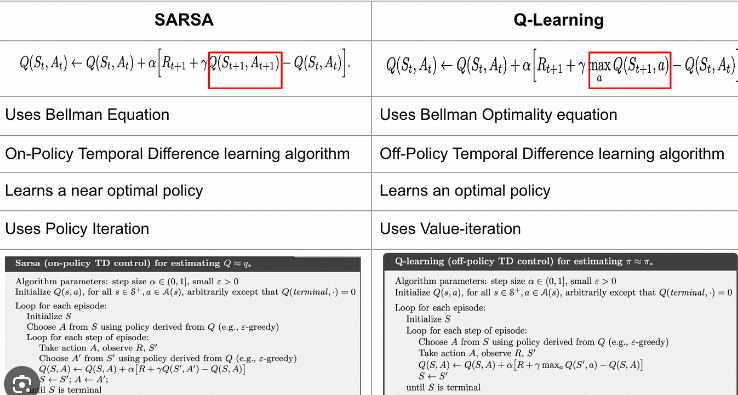

In [11]:
sim_params = SimulationParameters(num_days, num_simulations, decision_rolling_period)
supply_chain_data = construct_supply_chain_data(simulated_demand, mfg_site_capacity, std_dev_demand, adj_opening_cost, transport_cost_m_to_d, transport_cost_d_to_c)

In [12]:
# Training the agent
agent = QLearningAgent(supply_chain_data, sim_params)
learning_method = 'qlearning' # Can use qlearning or SARSA

n_episodes = 10000
agent.train(n_episodes, learning_method)

In [13]:
optimal_policy = agent.get_optimal_policy()
print(f"Optimal Policy: {optimal_policy[0]}")
print(f"Total RF Penalty: {optimal_policy[1]}")

Optimal Policy: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Total RF Penalty: -15985.0


In [14]:
def evaluate_daily_optimal_policy(agent, num_days):
    optimal_policy, total_penalty = agent.get_optimal_policy()
    total_cost = 0
    agent.reset()  # Reset the environment to initial state

    for day in range(num_days):
        daily_cost = 0
        # Get the optimal action for this state
        action = optimal_policy[day]
        
        # Take a step in the environment using the optimal action
        reward = agent.step(day, action)
        
        # Calculate the step cost (negative reward represents cost)
        daily_cost += reward

        total_cost += daily_cost
        print(f"Day {day}: Daily Cost = {daily_cost:.2f}, Total Cost = {total_cost:.2f}, Action = {action}")

    return total_cost, total_penalty

total_cost, total_penalty = evaluate_daily_optimal_policy(agent, num_days)
print(f"Total cost following optimal policy: {total_cost:.2f}")
print(f'RF Total penalty: {total_penalty:.2f}')


Day 0: Daily Cost = -1958.50, Total Cost = -1958.50, Action = 3
Day 1: Daily Cost = -1558.50, Total Cost = -3517.00, Action = 3
Day 2: Daily Cost = -1558.50, Total Cost = -5075.50, Action = 3
Day 3: Daily Cost = -1558.50, Total Cost = -6634.00, Action = 3
Day 4: Daily Cost = -1558.50, Total Cost = -8192.50, Action = 3
Day 5: Daily Cost = -1558.50, Total Cost = -9751.00, Action = 3
Day 6: Daily Cost = -1558.50, Total Cost = -11309.50, Action = 3
Day 7: Daily Cost = -1558.50, Total Cost = -12868.00, Action = 3
Day 8: Daily Cost = -1558.50, Total Cost = -14426.50, Action = 3
Day 9: Daily Cost = -1558.50, Total Cost = -15985.00, Action = 3
Total cost following optimal policy: -15985.00
RF Total penalty: -15985.00
